In [1]:
%matplotlib inline
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sns.set() # seaborn's method to set its chart style


In [9]:
#importando os dados
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

print(df.head(5))
print(df.tail())
print(df.info())
print(df.describe())
print(df.value_counts())
# view the data  types of each column
print(df.dtypes)

         Date   Time                            Location  \
0  09/17/1908  17:18                 Fort Myer, Virginia   
1  07/12/1912  06:30             AtlantiCity, New Jersey   
2  08/06/1913    NaN  Victoria, British Columbia, Canada   
3  09/09/1913  18:30                  Over the North Sea   
4  10/17/1913  10:30          Near Johannisthal, Germany   

                 Operator Flight #          Route                    Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1    Military - U.S. Navy      NaN    Test flight               Dirigible   
2                 Private        -            NaN        Curtiss seaplane   
3  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   
4  Military - German Navy      NaN            NaN  Zeppelin L-2 (airship)   

  Registration cn/In  Aboard  Fatalities  Ground  \
0          NaN     1     2.0         1.0     0.0   
1          NaN   NaN     5.0         5.0     0.0   
2          NaN   NaN

In [ ]:
# verificação de valores nulos, neste caso não existem 
df.info()
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5268 non-null   object 
 1   Time          3049 non-null   object 
 2   Location      5248 non-null   object 
 3   Operator      5250 non-null   object 
 4   Flight #      1069 non-null   object 
 5   Route         3561 non-null   object 
 6   Type          5241 non-null   object 
 7   Registration  4933 non-null   object 
 8   cn/In         4040 non-null   object 
 9   Aboard        5246 non-null   float64
 10  Fatalities    5256 non-null   float64
 11  Ground        5246 non-null   float64
 12  Summary       4878 non-null   object 
dtypes: float64(3), object(10)
memory usage: 535.2+ KB
None
         Date   Time                            Location  \
0  09/17/1908  17:18                 Fort Myer, Virginia   
1  07/12/1912  06:30             AtlantiCity, New Jersey   
2  08/06

In [20]:
#Tratar valores duplicados
df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [17]:
# 2. Processamento de Dados
## Criar coluna: Proporção de fatalidades por pessoas a bordo
df['Fatalities_Percentage'] = (df['Fatalities'] / df['Aboard']).fillna(0)

## Agrupamento: Número médio de fatalidades por operador
fatalities_by_operator = df.groupby('Operator')['Fatalities'].mean().sort_values(ascending=False).head(10)
print(fatalities_by_operator)

## Filtragem: Acidentes com mais de 100 fatalidades
high_fatalities = df[df['Fatalities'] > 100]
print(high_fatalities)

Operator
Pan American World Airways / KLM              583.0
Saudi Arabian Airlines / Kazastan Airlines    349.0
Military - IslamiRevolution's Guards Corps    275.0
Nationair (chartered by Nigeria Airways)      261.0
Arrow Airways                                 256.0
Lauda Air                                     223.0
Alas Nacionales, leased from Birgen Air       189.0
Inex Adria Aviopromet (Yugoslavia)            180.0
Inex Adria Aviopromet / British Airways       176.0
Surinam Airways                               176.0
Name: Fatalities, dtype: float64
            Date   Time                                           Location  \
1270  06/18/1953  16:34                        Tachikawa AFB, Tokyo, Japan   
1433  06/30/1956  10:32                              Grand Canyon, Arizona   
1701  12/16/1960  10:33                 Staten Island / Brooklyn, New York   
1759  03/04/1962  18:20                                   Douala, Cameroon   
1765  03/15/1962  00:30                Western P

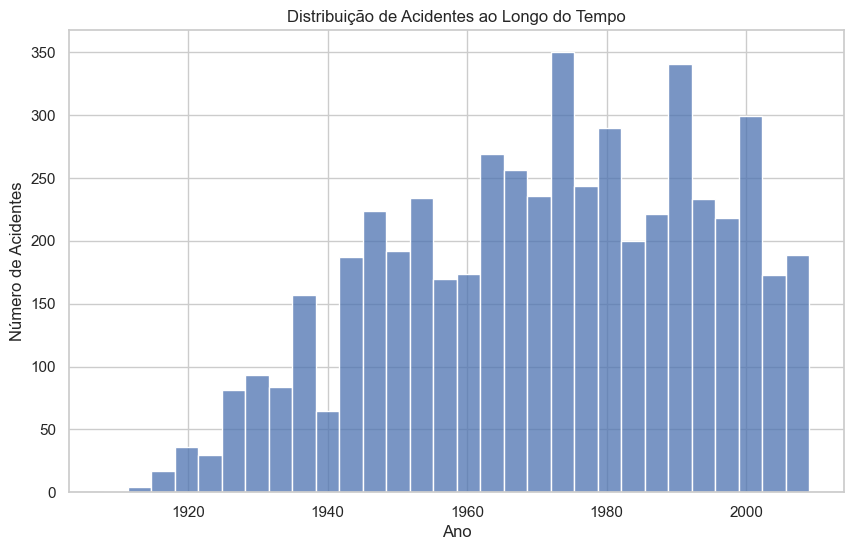

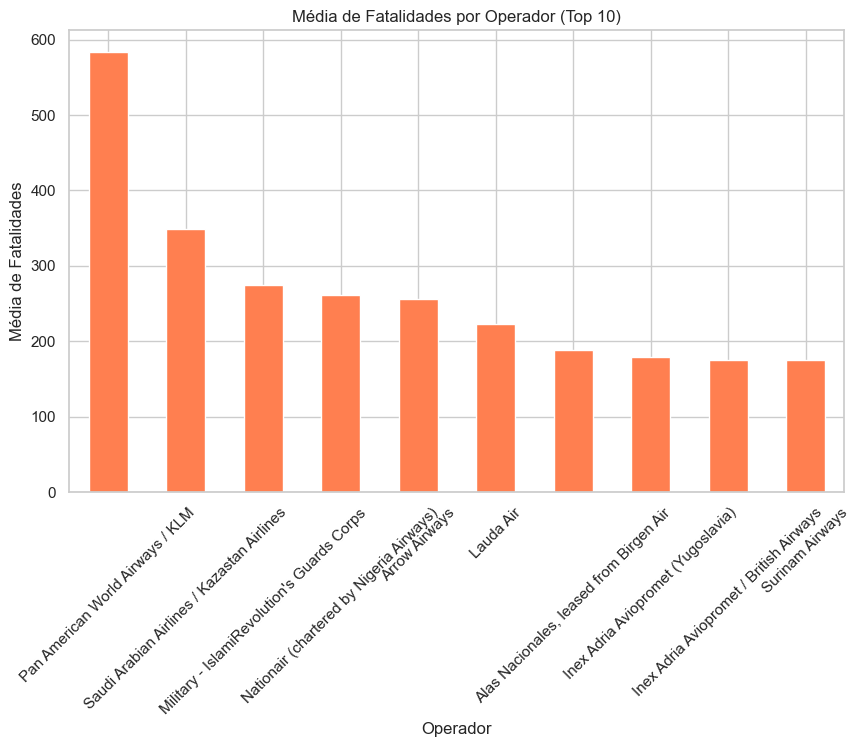

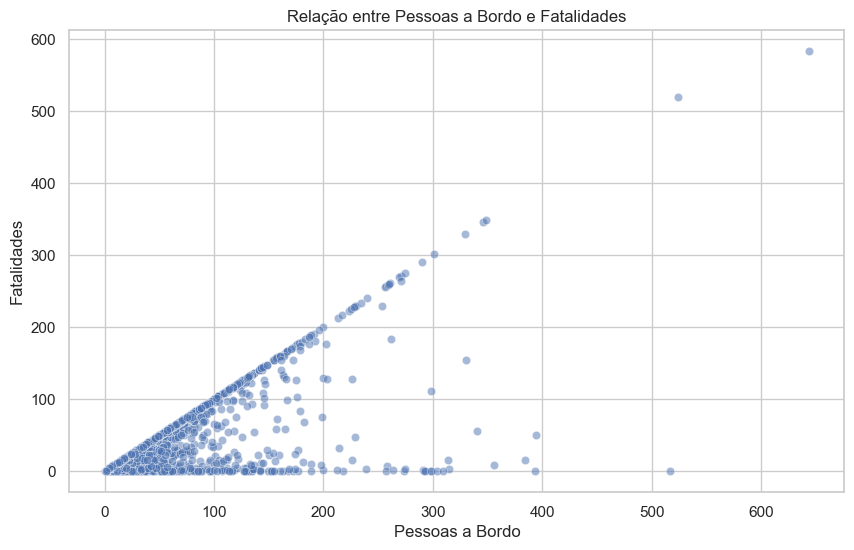

In [21]:
# 3. Visualização de Dados
sns.set(style="whitegrid")

# Gráfico 1: Distribuição de acidentes ao longo do tempo
plt.figure(figsize=(10, 6))
df = df.dropna(subset=['Date'])  
df['Year'] = df['Date'].dt.year
sns.histplot(df['Year'], bins=30, kde=False)
plt.title('Distribuição de Acidentes ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Número de Acidentes')
plt.show()

# Gráfico 2: Operadores com mais fatalidades
plt.figure(figsize=(10, 6))
fatalities_by_operator.plot(kind='bar', color='coral')
plt.title('Média de Fatalidades por Operador (Top 10)')
plt.xlabel('Operador')
plt.ylabel('Média de Fatalidades')
plt.xticks(rotation=45)
plt.show()

# Gráfico 3: Relação entre pessoas a bordo e fatalidades
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Aboard', y='Fatalities', data=df, alpha=0.5)
plt.title('Relação entre Pessoas a Bordo e Fatalidades')
plt.xlabel('Pessoas a Bordo')
plt.ylabel('Fatalidades')
plt.show()
